In [497]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm


In [498]:
# References
# https://datatas.com/how-to-use-variational-autoencoders-for-large-scale-data-compression/

In [499]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25

In [500]:
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    # print(encoded_width, encoded_height, np.log2(num_embeddings))
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    
    # 267 % 256 = 11
    return total.astype(np.uint8)

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount) * encoded_patch_bits

# TODO: test the method
def _get_compression_ratio(n_hits_total: int, patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> float:
    
    total_bits = _get_total_hit_bits(n_hits_total)
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
    event_patches_adcs = [
        event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
        for event_patch_flat in event_patches_adcs_flat
    ]
    return len(event_patches_adcs)

    
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())
            
def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()

In [501]:
# Loading data

pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 244.02it/s]


In [502]:
batch_size = 128
beta = 1e-3
learning_rate = 1e-8
num_epochs = 120
channels = 1
latent_dim = 16
# num_embeddings = 256 
LOG_EVERY = 10


In [503]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [504]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [505]:
event_train = events_train[:SELECTED_EVENTS][0]

In [506]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
        ]
        
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [507]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0], std=[1])    
])

event_dataset = PixelPatchesDataset(event_train, transform)

# Training data prepearation
train_loader = DataLoader(
    dataset=event_dataset, 
    batch_size=batch_size
)

# Test data preparation
# TODO: apply after the training examples are good
events_test_loaders = []

for event_test in events_test:
    event_dataset = PixelPatchesDataset(event_test, transform)

    event_test_loader = DataLoader(
        dataset=event_dataset, 
        batch_size=batch_size
    )
    events_test_loaders.append(event_test_loader)

In [508]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor, 
    mu: torch.tensor, 
    logvar: torch.tensor
) -> float:
    recon_loss = F.mse_loss(
        recon_x, 
        x, 
        reduction="sum"
    ) / x.size(0)
    
    # recon_loss = F.binary_cross_entropy_with_logits(recon_x, x)
    
    # KL_divergence
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp(),
        dim=1
    ).mean()
    
    return recon_loss + beta * kl_loss

In [509]:
class VAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1),  
            nn.ReLU(),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1),
            nn.ReLU(),            
            # nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1),
        )
        # self.flatten = nn.Flatten()
        self.fc_mean = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        self.fc_log_var = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        # self.fc_mean = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )
        torch.nn.init.xavier_uniform_(self.fc_mean.weight)
        
        # self.fc_log_var = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )        
        torch.nn.init.xavier_uniform_(self.fc_log_var.weight)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_channels * 2, channels, kernel_size=kernel_size, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar) :
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std) #here is the assumption p(z)=N(0,I)
        return mu + std * eps
        
        
    def forward(self, x):
        # apply convolutional layers with relu activation function
        # print("x range:", x.min().item(), x.max().item())
        
        x_encoded = self.encoder(x)
        
        # x_flatten = self.flatten(x_encoded)
        
        # get the mean and log variance of the latent space distribution
        z_log_mean = self.fc_mean(x_encoded)
        z_log_var = self.fc_log_var(x_encoded)
        
        self.z_log_mean = torch.clamp(z_log_mean, min=-10, max=10)
        self.z_log_var = torch.clamp(z_log_var, min=-2, max=5)
        
        # sample a latent vector using the reparameterization trick
        
        z = self.reparameterize(self.z_log_mean, self.z_log_var)
        
        output = self.decoder(z)
        
        return output, self.z_log_mean, self.z_log_var

In [510]:
model = VAE(
    hidden_channels=2, 
    kernel_size = 3
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/120: 100%|██████████| 124/124 [00:00<00:00, 596.04it/s, Loss=16.2]


Epoch [1/120] Average Loss: 16.1895
Before compression
Before: (128, 8, 8)


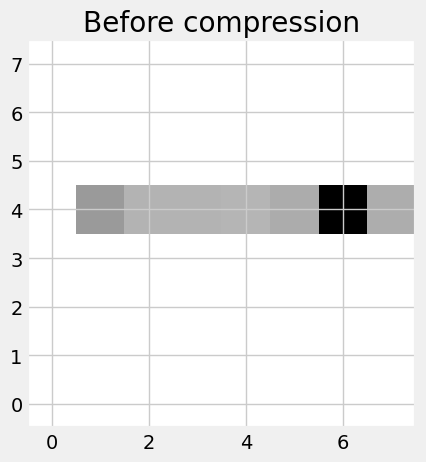

After: (1, 8, 8)
After compression


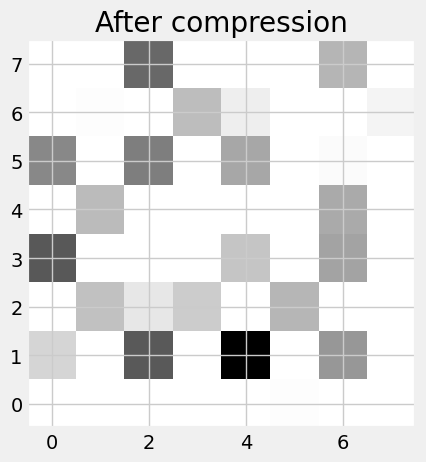

Epoch 2/120: 100%|██████████| 124/124 [00:00<00:00, 605.76it/s, Loss=16.2]


Epoch [2/120] Average Loss: 16.1893


Epoch 3/120: 100%|██████████| 124/124 [00:00<00:00, 607.98it/s, Loss=16.3]


Epoch [3/120] Average Loss: 16.1855


Epoch 4/120: 100%|██████████| 124/124 [00:00<00:00, 596.56it/s, Loss=16.2]


...

Epoch [9/120] Average Loss: 16.1877


Epoch 10/120: 100%|██████████| 124/124 [00:00<00:00, 593.07it/s, Loss=16.2]


Epoch [10/120] Average Loss: 16.1873


Epoch 11/120: 100%|██████████| 124/124 [00:00<00:00, 595.57it/s, Loss=16.2]


Epoch [11/120] Average Loss: 16.1885
Before compression
Before: (128, 8, 8)


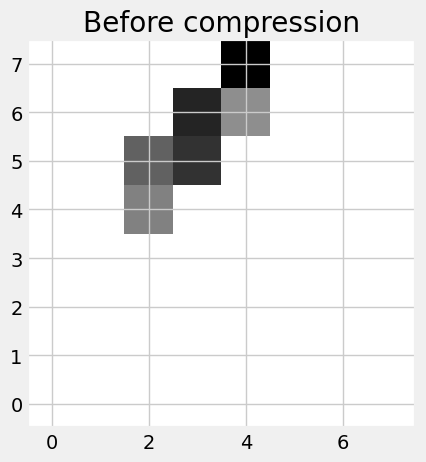

After: (1, 8, 8)
After compression


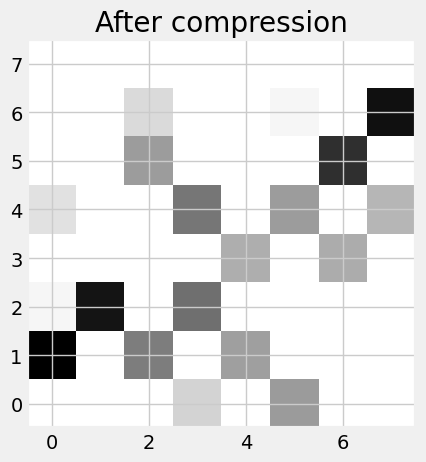

Epoch 12/120: 100%|██████████| 124/124 [00:00<00:00, 584.57it/s, Loss=16.2]


Epoch [12/120] Average Loss: 16.1902


Epoch 13/120: 100%|██████████| 124/124 [00:00<00:00, 587.85it/s, Loss=16.2]


Epoch [13/120] Average Loss: 16.1903


Epoch 14/120: 100%|██████████| 124/124 [00:00<00:00, 590.60it/s, Loss=16.2]


...

Epoch [19/120] Average Loss: 16.1851


Epoch 20/120: 100%|██████████| 124/124 [00:00<00:00, 583.04it/s, Loss=16.2]


Epoch [20/120] Average Loss: 16.1843


Epoch 21/120: 100%|██████████| 124/124 [00:00<00:00, 580.13it/s, Loss=16.2]


Epoch [21/120] Average Loss: 16.1872
Before compression
Before: (128, 8, 8)


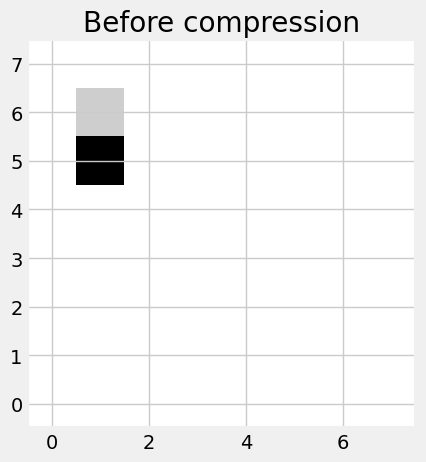

After: (1, 8, 8)
After compression


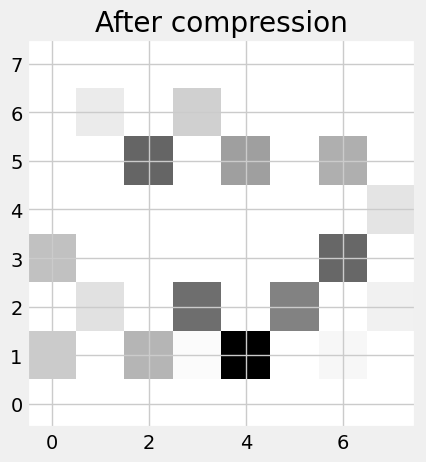

Epoch 22/120: 100%|██████████| 124/124 [00:00<00:00, 576.58it/s, Loss=16.2]


Epoch [22/120] Average Loss: 16.1916


Epoch 23/120: 100%|██████████| 124/124 [00:00<00:00, 587.18it/s, Loss=16.2]


Epoch [23/120] Average Loss: 16.1862


Epoch 24/120: 100%|██████████| 124/124 [00:00<00:00, 592.64it/s, Loss=16.3]


...

Epoch [29/120] Average Loss: 16.1887


Epoch 30/120: 100%|██████████| 124/124 [00:00<00:00, 577.71it/s, Loss=16.2]


Epoch [30/120] Average Loss: 16.1913


Epoch 31/120: 100%|██████████| 124/124 [00:00<00:00, 598.37it/s, Loss=16.2]


Epoch [31/120] Average Loss: 16.1922
Before compression
Before: (128, 8, 8)


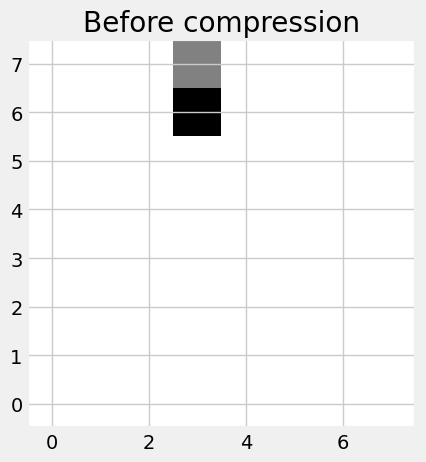

After: (1, 8, 8)
After compression


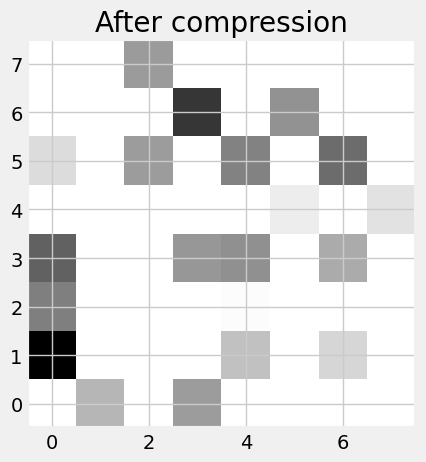

Epoch 32/120: 100%|██████████| 124/124 [00:00<00:00, 596.25it/s, Loss=16.2]


Epoch [32/120] Average Loss: 16.1877


Epoch 33/120: 100%|██████████| 124/124 [00:00<00:00, 609.48it/s, Loss=16.2]


Epoch [33/120] Average Loss: 16.1919


Epoch 34/120: 100%|██████████| 124/124 [00:00<00:00, 615.18it/s, Loss=16.2]


...

Epoch [39/120] Average Loss: 16.1926


Epoch 40/120: 100%|██████████| 124/124 [00:00<00:00, 580.86it/s, Loss=16.2]


Epoch [40/120] Average Loss: 16.1877


Epoch 41/120: 100%|██████████| 124/124 [00:00<00:00, 588.65it/s, Loss=16.2]


Epoch [41/120] Average Loss: 16.1870
Before compression
Before: (128, 8, 8)


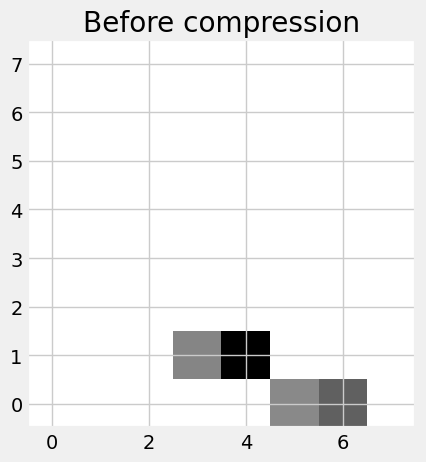

After: (1, 8, 8)
After compression


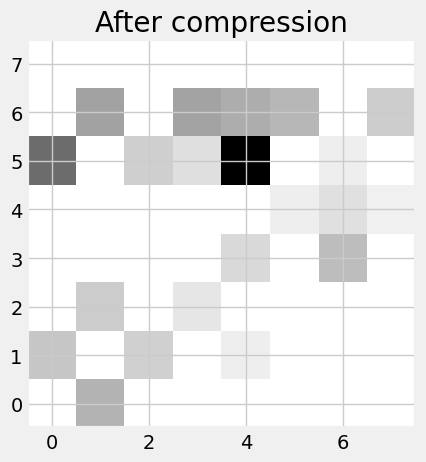

Epoch 42/120: 100%|██████████| 124/124 [00:00<00:00, 582.20it/s, Loss=16.2]


Epoch [42/120] Average Loss: 16.1886


Epoch 43/120: 100%|██████████| 124/124 [00:00<00:00, 575.56it/s, Loss=16.2]


Epoch [43/120] Average Loss: 16.1872


Epoch 44/120: 100%|██████████| 124/124 [00:00<00:00, 578.06it/s, Loss=16.2]


...

Epoch [49/120] Average Loss: 16.1880


Epoch 50/120: 100%|██████████| 124/124 [00:00<00:00, 568.94it/s, Loss=16.2]


Epoch [50/120] Average Loss: 16.1894


Epoch 51/120: 100%|██████████| 124/124 [00:00<00:00, 584.21it/s, Loss=16.2]


Epoch [51/120] Average Loss: 16.1881
Before compression
Before: (128, 8, 8)


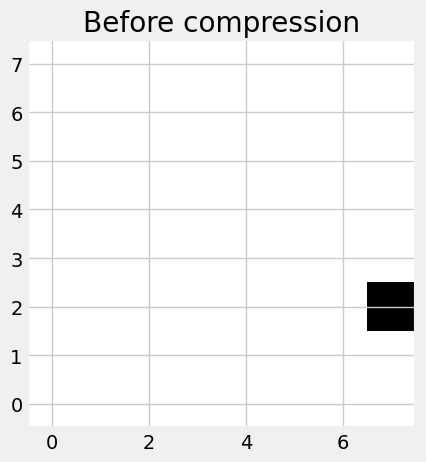

After: (1, 8, 8)
After compression


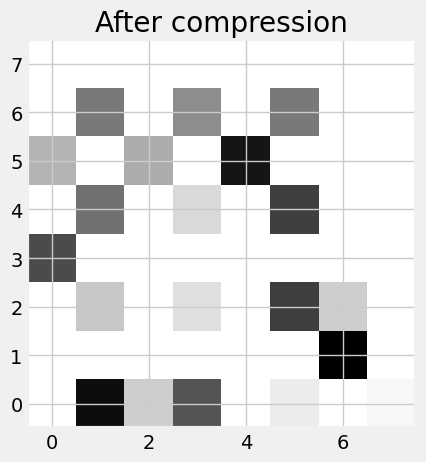

Epoch 52/120: 100%|██████████| 124/124 [00:00<00:00, 588.22it/s, Loss=16.2]


Epoch [52/120] Average Loss: 16.1875


Epoch 53/120: 100%|██████████| 124/124 [00:00<00:00, 594.95it/s, Loss=16.2]


Epoch [53/120] Average Loss: 16.1907


Epoch 54/120: 100%|██████████| 124/124 [00:00<00:00, 584.67it/s, Loss=16.2]


...

Epoch [59/120] Average Loss: 16.1891


Epoch 60/120: 100%|██████████| 124/124 [00:00<00:00, 587.12it/s, Loss=16.2]


Epoch [60/120] Average Loss: 16.1866


Epoch 61/120: 100%|██████████| 124/124 [00:00<00:00, 577.16it/s, Loss=16.2]


Epoch [61/120] Average Loss: 16.1887
Before compression
Before: (128, 8, 8)


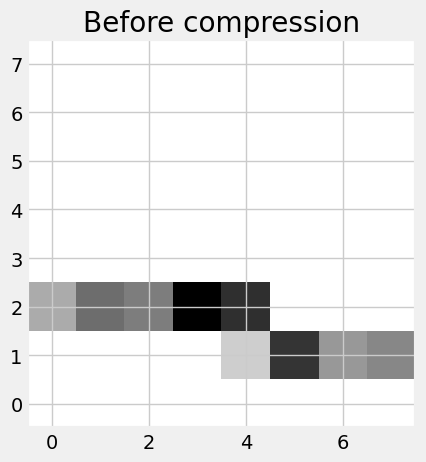

After: (1, 8, 8)
After compression


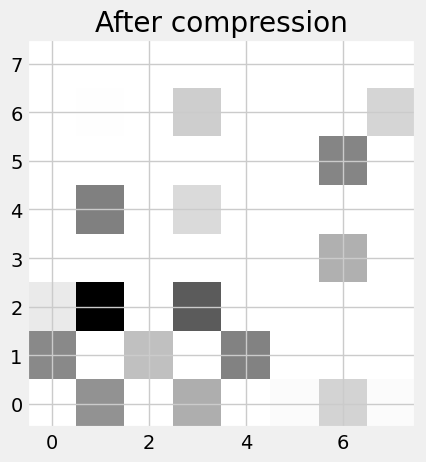

Epoch 62/120: 100%|██████████| 124/124 [00:00<00:00, 579.31it/s, Loss=16.2]


Epoch [62/120] Average Loss: 16.1824


Epoch 63/120: 100%|██████████| 124/124 [00:00<00:00, 581.79it/s, Loss=16.2]


Epoch [63/120] Average Loss: 16.1866


Epoch 64/120: 100%|██████████| 124/124 [00:00<00:00, 581.51it/s, Loss=16.2]


...

Epoch [69/120] Average Loss: 16.1871


Epoch 70/120: 100%|██████████| 124/124 [00:00<00:00, 604.82it/s, Loss=16.2]


Epoch [70/120] Average Loss: 16.1906


Epoch 71/120: 100%|██████████| 124/124 [00:00<00:00, 592.43it/s, Loss=16.3]


Epoch [71/120] Average Loss: 16.1907
Before compression
Before: (128, 8, 8)


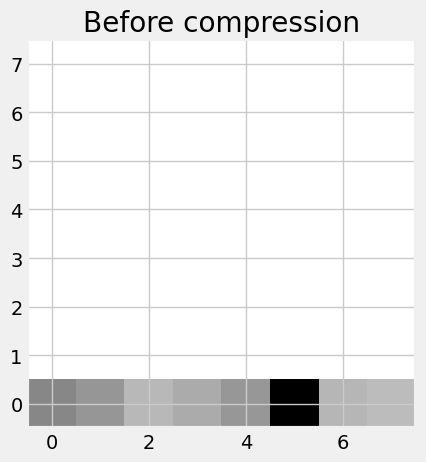

After: (1, 8, 8)
After compression


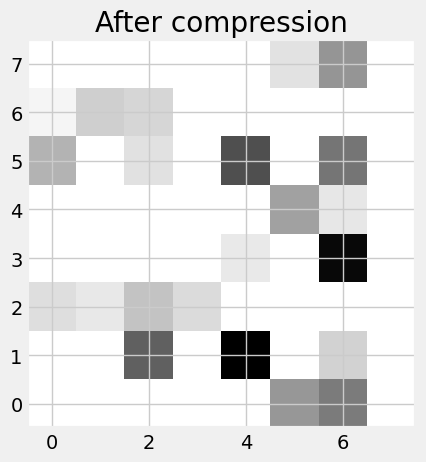

Epoch 72/120: 100%|██████████| 124/124 [00:00<00:00, 576.51it/s, Loss=16.2]


Epoch [72/120] Average Loss: 16.1865


Epoch 73/120: 100%|██████████| 124/124 [00:00<00:00, 581.00it/s, Loss=16.2]


Epoch [73/120] Average Loss: 16.1851


Epoch 74/120: 100%|██████████| 124/124 [00:00<00:00, 585.53it/s, Loss=16.2]


...

Epoch [79/120] Average Loss: 16.1888


Epoch 80/120: 100%|██████████| 124/124 [00:00<00:00, 587.89it/s, Loss=16.2]


Epoch [80/120] Average Loss: 16.1883


Epoch 81/120: 100%|██████████| 124/124 [00:00<00:00, 586.79it/s, Loss=16.2]


Epoch [81/120] Average Loss: 16.1866
Before compression
Before: (128, 8, 8)


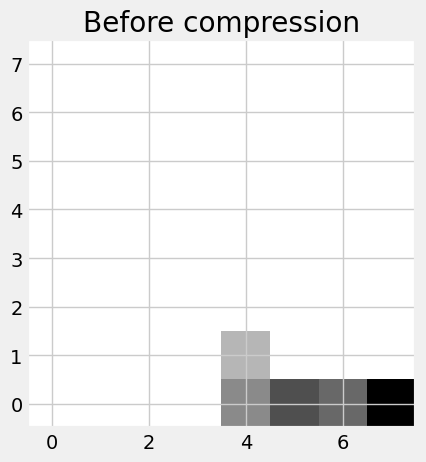

After: (1, 8, 8)
After compression


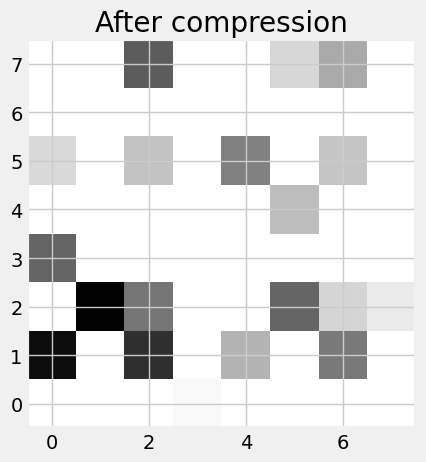

Epoch 82/120: 100%|██████████| 124/124 [00:00<00:00, 579.59it/s, Loss=16.2]


Epoch [82/120] Average Loss: 16.1849


Epoch 83/120: 100%|██████████| 124/124 [00:00<00:00, 580.66it/s, Loss=16.3]


Epoch [83/120] Average Loss: 16.1885


Epoch 84/120: 100%|██████████| 124/124 [00:00<00:00, 583.15it/s, Loss=16.2]


...

Epoch [89/120] Average Loss: 16.1849


Epoch 90/120: 100%|██████████| 124/124 [00:00<00:00, 601.46it/s, Loss=16.2]


Epoch [90/120] Average Loss: 16.1884


Epoch 91/120: 100%|██████████| 124/124 [00:00<00:00, 595.50it/s, Loss=16.2]


Epoch [91/120] Average Loss: 16.1881
Before compression
Before: (128, 8, 8)


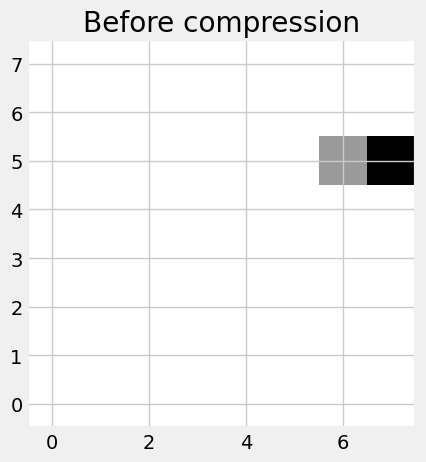

After: (1, 8, 8)
After compression


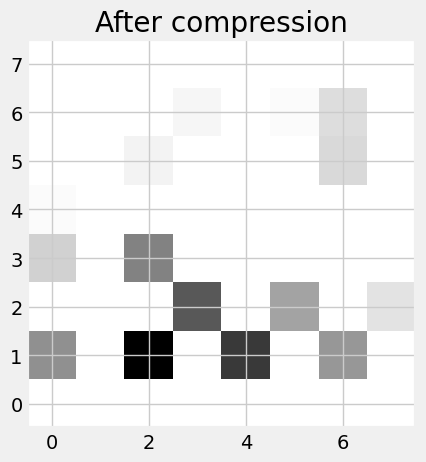

Epoch 92/120: 100%|██████████| 124/124 [00:00<00:00, 568.84it/s, Loss=16.2]


Epoch [92/120] Average Loss: 16.1849


Epoch 93/120: 100%|██████████| 124/124 [00:00<00:00, 577.36it/s, Loss=16.2]


Epoch [93/120] Average Loss: 16.1851


Epoch 94/120: 100%|██████████| 124/124 [00:00<00:00, 580.69it/s, Loss=16.2]


...

Epoch [99/120] Average Loss: 16.1894


Epoch 100/120: 100%|██████████| 124/124 [00:00<00:00, 598.64it/s, Loss=16.2]


Epoch [100/120] Average Loss: 16.1887


Epoch 101/120: 100%|██████████| 124/124 [00:00<00:00, 606.87it/s, Loss=16.2]


Epoch [101/120] Average Loss: 16.1901
Before compression
Before: (128, 8, 8)


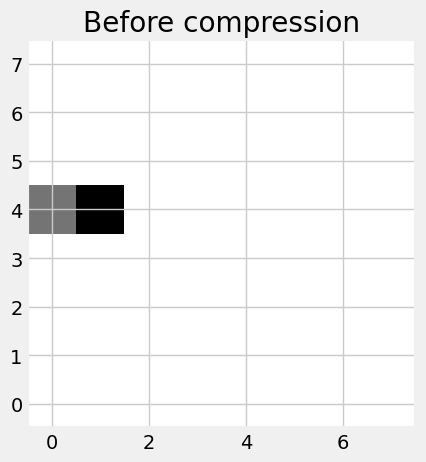

After: (1, 8, 8)
After compression


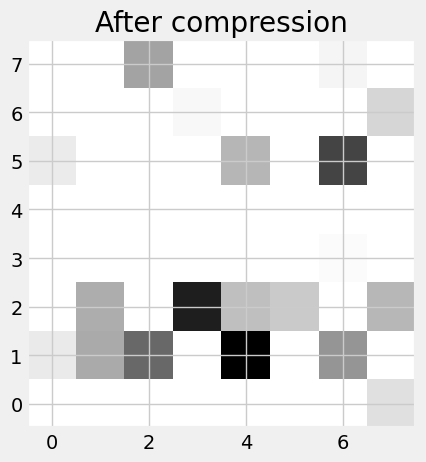

Epoch 102/120: 100%|██████████| 124/124 [00:00<00:00, 584.94it/s, Loss=16.2]


Epoch [102/120] Average Loss: 16.1865


Epoch 103/120: 100%|██████████| 124/124 [00:00<00:00, 600.94it/s, Loss=16.3]


Epoch [103/120] Average Loss: 16.1870


Epoch 104/120: 100%|██████████| 124/124 [00:00<00:00, 598.26it/s, Loss=16.3]


...

Epoch [109/120] Average Loss: 16.1861


Epoch 110/120: 100%|██████████| 124/124 [00:00<00:00, 581.14it/s, Loss=16.2]


Epoch [110/120] Average Loss: 16.1882


Epoch 111/120: 100%|██████████| 124/124 [00:00<00:00, 580.48it/s, Loss=16.2]


Epoch [111/120] Average Loss: 16.1875
Before compression
Before: (128, 8, 8)


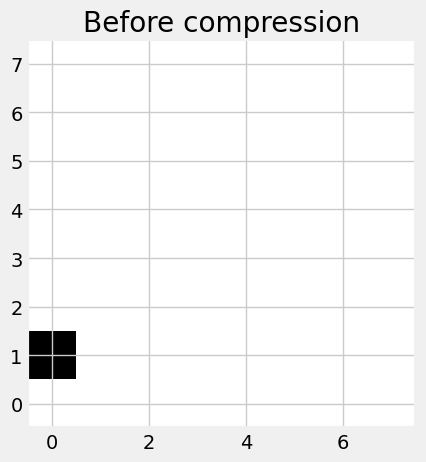

After: (1, 8, 8)
After compression


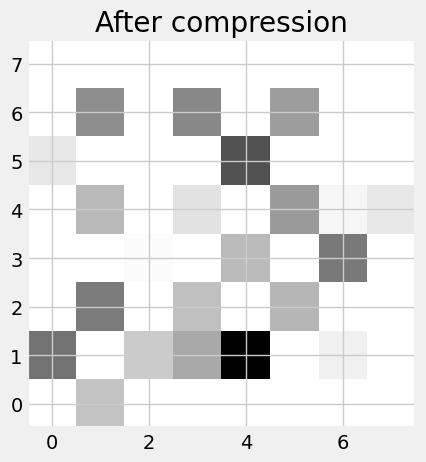

Epoch 112/120: 100%|██████████| 124/124 [00:00<00:00, 573.62it/s, Loss=16.2]


Epoch [112/120] Average Loss: 16.1840


Epoch 113/120: 100%|██████████| 124/124 [00:00<00:00, 585.37it/s, Loss=16.3]


Epoch [113/120] Average Loss: 16.1886


Epoch 114/120: 100%|██████████| 124/124 [00:00<00:00, 581.41it/s, Loss=16.2]


...

Epoch [118/120] Average Loss: 16.1845


Epoch 119/120: 100%|██████████| 124/124 [00:00<00:00, 586.77it/s, Loss=16.2]


Epoch [119/120] Average Loss: 16.1845


Epoch 120/120: 100%|██████████| 124/124 [00:00<00:00, 580.21it/s, Loss=16.2]


Epoch [120/120] Average Loss: 16.1861


In [511]:
average_loss = []
patches_before = []
patches_after = []

patch_test_cursor = iter(events_test_loaders[0])
model.train()

for epoch in range(num_epochs):
    train_loss = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        
        # Adding some randomness for regulating the small noisy areas
        # X_adcs = X_adcs + 0.01 * torch.randn_like(X_adcs)
        
        X_adcs = X_adcs.to(device)
        
    
        (
            recon_patch, 
            mu,
            logvar 
        ) = model(
           X_adcs
        )
        
        loss = _get_vae_loss(recon_patch, X_adcs, mu, logvar)
        
        recon_patch = recon_patch.float().to(device)      
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)
        
        train_loss += loss.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
        # scheduler.step()
        
        
    # Saving epoch  statistics
    
    avg_loss = train_loss / len(train_loader)
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')
    average_loss.append(avg_loss)
    
    if epoch % LOG_EVERY == 0:
        with torch.no_grad():            
            # selecting events before reconstruction using one test loader as validation
            patch_test = next(patch_test_cursor) 
            patch_test = patch_test.to(device)           
            print("Before compression")
            
            patch_test_ts = _tensor_to_numpy(
                patch_test.squeeze(1)
            )
            
            print(f"Before: {patch_test_ts.shape}")            
            plot_patch(patch_test_ts[0], "Before compression")
            
            patches_before.append(patch_test_ts[0])
            
            (
                recon_patch, 
                mu,
                logvar 
            ) = model(patch_test)
            
            recon_patch_np = _tensor_to_numpy(
                recon_patch[0]
            )
            print(f"After: {recon_patch_np.shape}")
            print("After compression")
            
            plot_patch(recon_patch_np[0], "After compression")
            
            patches_after.append(recon_patch_np[0])
        

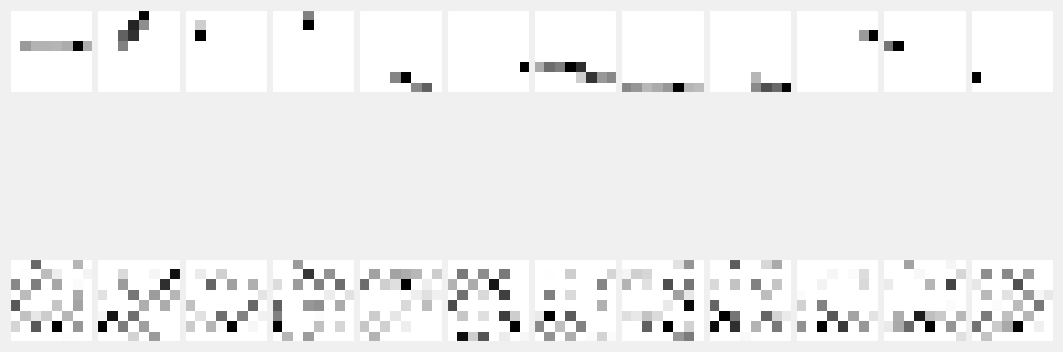

In [512]:
image_rows = [
    patches_before,
    patches_after
]
cols = len(image_rows[0])
rows = len(image_rows)

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i in range(rows):
    for j in range(cols):
        ax = axes[i, j]
        ax.imshow(image_rows[i][j], cmap='gist_yarg', origin='lower')
        
        ax.set_xticks([])
        ax.set_yticks([])
        
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

In [513]:
# TODO
# Improve gradients
_display_gradients(model)

Showing model gradients
encoder.0.weight 0.0003820355050265789
encoder.0.bias 0.0004641478881239891
encoder.2.weight 0.0001568870065966621
encoder.2.bias 0.19728609919548035
fc_mean.weight 0.007808109279721975
fc_mean.bias 0.35313189029693604
fc_log_var.weight 0.003369683865457773
fc_log_var.bias 0.15264441072940826
decoder.0.weight 0.9645848274230957
decoder.0.bias 0.870949387550354
decoder.2.weight 2.3287558555603027
decoder.2.bias 4.730937957763672


/tmp/ipykernel_2931921/1764288248.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


VAE, Average loss values over epochs


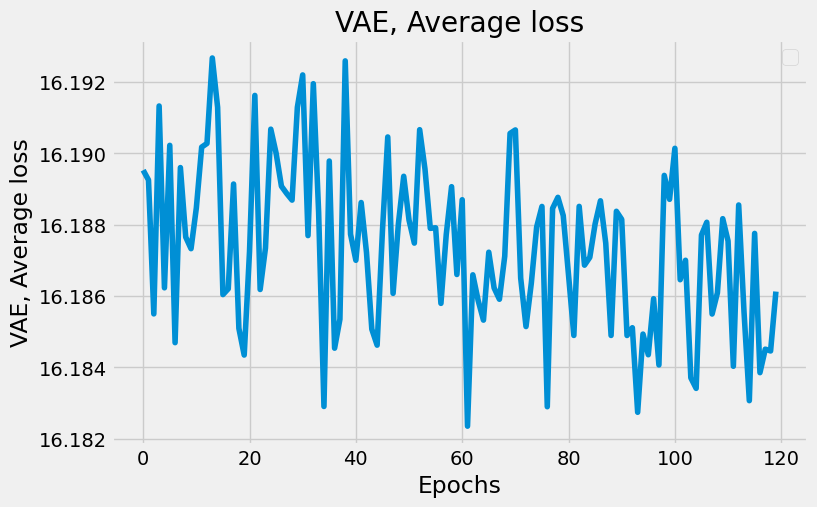

In [514]:
# display loss values
plot_metric_results(
    y_values=average_loss, 
    x_values=list(range(num_epochs)),
    y_title="VAE, Average loss",
    title="VAE, Average loss",
    x_label="Epochs"
)

In [515]:
# print(f"mu = {model.z_log_mean.mean().item()}")
# print(f"logvar = {model.z_log_var.std().item()}")